# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [43]:
# Install required packages (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn requests

In [44]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import gzip
import io
import ast
import warnings
warnings.filterwarnings('ignore')

# Set visual style for plots
sns.set_style('whitegrid')
%matplotlib inline

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

**Problem Statement:** I want to investigate the relationship between a movie's production budget and its audience reception (IMDb rating). Specifically, I aim to explore whether higher-budget movies tend to receive better ratings from viewers, and how this relationship varies across different genres. To answer this question, I will wrangle two datasets: (1) The Movies Metadata dataset from Kaggle, which contains information about budgets, revenues, genres, and release dates for over 45,000 movies, and (2) the IMDb Title Ratings dataset from IMDb's official data interface, which provides average ratings and vote counts for millions of titles.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government's open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

Type: CSV File

Method: The data was gathered using the **"Manual Download"** method from Kaggle (https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset). I chose this dataset because it is one of the most comprehensive publicly available movie datasets, containing detailed metadata for over 45,000 films. The dataset is well-known for having multiple data quality and tidiness issues, making it ideal for demonstrating data wrangling skills.

Dataset variables:

*   **budget**: The production budget of the movie in USD.
*   **genres**: A JSON-formatted string listing all genres associated with the movie.
*   **imdb_id**: The unique IMDb identifier for the movie (e.g., 'tt0114709').
*   **original_title**: The original title of the movie.
*   **revenue**: The worldwide box office revenue in USD.
*   **release_date**: The release date of the movie.
*   **vote_average**: The average vote score from TMDb users.
*   **vote_count**: The number of votes received on TMDb.

In [45]:
# Dataset 1: Load the movies metadata CSV file (already downloaded and stored as raw data)
# The file was originally from: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
# We use low_memory=False because the dataset has mixed types in some columns

# Check if file exists in current directory, otherwise specify the full path
import os
file_path = 'raw_movies_metadata.csv'
if not os.path.exists(file_path):
	# If not found, try alternative paths
	print(f"File '{file_path}' not found in current directory: {os.getcwd()}")
	print("Please ensure the raw_movies_metadata.csv file is in the same directory as this notebook")
else:
	df_movies = pd.read_csv(file_path, low_memory=False)
	
	# Display basic info about the dataset
	print(f'Dataset 1 shape: {df_movies.shape}')
	print(f'Number of rows: {df_movies.shape[0]}')
	print(f'Number of columns: {df_movies.shape[1]}')
	df_movies.head()

Dataset 1 shape: (45466, 24)
Number of rows: 45466
Number of columns: 24


#### Dataset 2

Type: TSV (Tab-Separated Values) compressed file (.tsv.gz)

Method: The data was gathered using the **"Programmatic Download"** method from IMDb's official datasets interface (https://datasets.imdbws.com/). I chose this dataset because it provides the authoritative IMDb average ratings and number of votes for each title, which serves as a reliable measure of audience reception. The programmatic download method allows reproducibility, as anyone can re-run the code to obtain the latest version of the data.

Dataset variables:

*   **tconst**: The unique alphanumeric identifier of the title (matches imdb_id in Dataset 1).
*   **averageRating**: The weighted average of all individual user ratings on IMDb (scale 1-10).
*   **numVotes**: The total number of votes the title has received on IMDb.

In [46]:
# Dataset 2: Programmatically download IMDb ratings data
# Source: https://datasets.imdbws.com/title.ratings.tsv.gz

url = 'https://datasets.imdbws.com/title.ratings.tsv.gz'
print(f'Downloading IMDb ratings data from: {url}')

# Download the compressed file using requests
response = requests.get(url)
print(f'Download status code: {response.status_code}')

# Decompress and read the TSV file into a DataFrame
compressed_data = gzip.decompress(response.content)
df_imdb = pd.read_csv(io.BytesIO(compressed_data), sep='\t')

# Display basic info about the dataset
print(f'\nDataset 2 shape: {df_imdb.shape}')
print(f'Number of rows: {df_imdb.shape[0]}')
print(f'Number of columns: {df_imdb.shape[1]}')
df_imdb.head()

Download status code: 200

Dataset 2 shape: (1661601, 3)
Number of rows: 1661601
Number of columns: 3


,tconst,averageRating,numVotes
0,tt0000001,5.7,2206
1,tt0000002,5.5,313
2,tt0000003,6.4,2318
3,tt0000004,5.1,197
4,tt0000005,6.2,3042


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [47]:
# Save raw datasets to local storage for backup before any processing
# Only save if both dataframes were successfully loaded
if 'df_movies' in dir() and 'df_imdb' in dir():
	df_movies.to_csv('raw_movies_metadata.csv', index=False)
	df_imdb.to_csv('raw_imdb_ratings.csv', index=False)
	print('Raw datasets saved successfully:')
	print('  - raw_movies_metadata.csv')
	print('  - raw_imdb_ratings.csv')
else:
	print('Warning: Could not save raw datasets.')
	print('Please ensure movies_metadata.csv is downloaded and placed in the current directory.')
	print('Download from: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset')

Raw datasets saved successfully:
  - raw_movies_metadata.csv
  - raw_imdb_ratings.csv


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Corrupted rows with non-numeric IDs in movies_metadata

In [48]:
# Visual assessment: Display a sample of the 'id' column to spot non-numeric entries
# We use head(20) to visually scan for any rows that look out of place
if 'df_movies' in dir():
	print('Visual inspection of the id column (first 20 rows):')
	df_movies[['id', 'original_title', 'budget']].head(20)
else:
	print('Error: df_movies not loaded. Please run Cell 10 first and ensure movies_metadata.csv is in your working directory.')
	print('Download the file from: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset')

Visual inspection of the id column (first 20 rows):


In [49]:
# Programmatic assessment: Check how many rows have non-numeric 'id' values
# The 'id' column should contain only integers. Non-numeric values indicate corrupted rows
# where data from other columns has shifted into wrong positions.
if 'df_movies' in dir():
	non_numeric_ids = df_movies[pd.to_numeric(df_movies['id'], errors='coerce').isna()]
	print(f'Number of rows with non-numeric id values: {len(non_numeric_ids)}')
	print(f'Total rows in dataset: {len(df_movies)}')
	print(f'Percentage corrupted: {len(non_numeric_ids)/len(df_movies)*100:.2f}%')
	print('\nCorrupted rows:')
	non_numeric_ids[['id', 'original_title', 'budget']].head()
else:
	print('Error: df_movies not loaded. Please run Cell 10 first and ensure movies_metadata.csv is in your working directory.')
	print('Download the file from: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset')

Number of rows with non-numeric id values: 3
Total rows in dataset: 45466
Percentage corrupted: 0.01%

Corrupted rows:


Issue and justification: **The movies_metadata dataset contains corrupted rows where the data is shifted** — non-numeric values appear in the `id` column (which should only contain integers). These rows represent data integrity failures where fields from one column have spilled into another. I used `pd.to_numeric()` with `errors='coerce'` to programmatically detect all rows where the `id` field cannot be converted to a number. This is a **Validity** issue under data quality, as these values do not conform to the expected data type and format for the `id` column.

### Quality Issue 2: Invalid zero values in the budget column representing missing data

In [50]:
# Visual assessment: Display rows where budget is 0 to confirm they look like missing values
# rather than actual zero-budget movies
print('Sample of movies with budget = 0:')
df_movies[df_movies['budget'] == '0'][['original_title', 'budget', 'revenue']].head(10)

Sample of movies with budget = 0:


,original_title,budget,revenue
2,Grumpier Old Men,0,0.0
4,Father of the Bride Part II,0,76578911.0
7,Tom and Huck,0,0.0
11,Dracula: Dead and Loving It,0,0.0
12,Balto,0,11348324.0
21,Copycat,0,0.0
23,Powder,0,0.0
25,Othello,0,0.0
27,Persuasion,0,0.0
29,摇啊摇，摇到外婆桥,0,0.0


In [51]:
# Programmatic assessment: Count how many movies have budget = 0 or missing
# Many well-known movies show budget as 0, which is clearly not accurate.
# This indicates the value is missing/unknown, not actually zero.
budget_zero_count = (df_movies['budget'] == '0').sum() + (df_movies['budget'] == 0).sum()
budget_null_count = df_movies['budget'].isna().sum()
total = len(df_movies)
print(f'Rows with budget = 0: {budget_zero_count}')
print(f'Rows with budget = NaN: {budget_null_count}')
print(f'Total rows: {total}')
print(f'Percentage with zero/missing budget: {(budget_zero_count + budget_null_count)/total*100:.1f}%')

# Also check data type of budget column
print(f'\nBudget column dtype: {df_movies["budget"].dtype}')

Rows with budget = 0: 36573
Rows with budget = NaN: 0
Total rows: 45466
Percentage with zero/missing budget: 80.4%

Budget column dtype: object


Issue and justification: **A large number of movies have a budget value of 0, which represents missing/unknown data rather than actual zero-budget productions.** Additionally, the `budget` column is stored as an `object` (string) type instead of numeric. I used value counting to programmatically quantify the scope of this issue, and visual inspection confirmed that well-known movies with clearly substantial budgets are listed as 0. This is a **Completeness** and **Validity** issue — the zero values mask truly missing data, and the column type prevents numerical analysis.

### Tidiness Issue 1: Same observational unit (movies) split across two tables

In [52]:
# Visual assessment: Show that both datasets contain information about the same movies
# but are stored in separate tables
print('Dataset 1 (movies_metadata) columns:')
print(df_movies.columns.tolist())
print(f'\nDataset 1 sample imdb_id values:')
print(df_movies['imdb_id'].head())
print(f'\nDataset 2 (IMDb ratings) columns:')
print(df_imdb.columns.tolist())
print(f'\nDataset 2 sample tconst values:')
print(df_imdb['tconst'].head())

Dataset 1 (movies_metadata) columns:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

Dataset 1 sample imdb_id values:
0    tt0114709
1    tt0113497
2    tt0113228
3    tt0114885
4    tt0113041
Name: imdb_id, dtype: object

Dataset 2 (IMDb ratings) columns:
['tconst', 'averageRating', 'numVotes']

Dataset 2 sample tconst values:
0    tt0000001
1    tt0000002
2    tt0000003
3    tt0000004
4    tt0000005
Name: tconst, dtype: object


In [53]:
# Programmatic assessment: Verify the datasets share a common key (IMDb ID)
# and count how many movies exist in both datasets
common_ids = set(df_movies['imdb_id'].dropna()) & set(df_imdb['tconst'])
print(f'Movies in Dataset 1: {len(df_movies)}')
print(f'Titles in Dataset 2: {len(df_imdb)}')
print(f'Common titles (shared IMDb IDs): {len(common_ids)}')
print(f'\nBoth datasets describe the same entity (movies) but are stored separately.')
print('This violates the 3rd tidiness rule: each observational unit should form a single table.')

Movies in Dataset 1: 45466
Titles in Dataset 2: 1661601
Common titles (shared IMDb IDs): 45349

Both datasets describe the same entity (movies) but are stored separately.
This violates the 3rd tidiness rule: each observational unit should form a single table.


Issue and justification: **Both datasets describe the same observational unit (movies) but are stored in separate tables.** Dataset 1 contains movie metadata (budget, genre, title) and Dataset 2 contains IMDb ratings — all of which are attributes of the same entity. This violates the third tidiness rule: *Each type of observational unit forms a table.* I verified this programmatically by confirming the datasets share a common key (`imdb_id` / `tconst`) and that thousands of movies appear in both tables. The solution is to merge the two datasets.

### Tidiness Issue 2: Multiple values (genres) packed into a single column as JSON strings

In [54]:
# Visual assessment: Display the genres column to show the JSON-encoded format
# Each cell contains a list of dictionaries rather than a simple value
print('Sample of the genres column:')
for i, row in df_movies[['original_title', 'genres']].head(5).iterrows():
    print(f'  {row["original_title"]}: {row["genres"][:80]}...')

Sample of the genres column:
  Toy Story: [{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'n...
  Jumanji: [{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, '...
  Grumpier Old Men: [{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]...
  Waiting to Exhale: [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name'...
  Father of the Bride Part II: [{'id': 35, 'name': 'Comedy'}]...


In [55]:
# Programmatic assessment: Check the structure of the genres column
# Each entry is a string representation of a list of dictionaries
print(f'Genres column dtype: {df_movies["genres"].dtype}')
print(f'\nExample raw value:')
print(df_movies['genres'].iloc[0])
print(f'\nType of a single entry: {type(df_movies["genres"].iloc[0])}')

# Parse one entry to show the structure
try:
    parsed = ast.literal_eval(df_movies['genres'].iloc[0])
    print(f'\nParsed structure: {parsed}')
    print(f'Type after parsing: {type(parsed)}')
except:
    print('Could not parse entry')

Genres column dtype: object

Example raw value:
[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]

Type of a single entry: <class 'str'>

Parsed structure: [{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]
Type after parsing: <class 'list'>


Issue and justification: **The `genres` column contains JSON-encoded strings (lists of dictionaries) instead of having each genre as a usable value.** For example, a movie's genres are stored as `[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}]` — a complex nested structure within a single cell. This violates the first tidiness rule: *Each variable forms a column.* The genre information is not directly accessible for analysis without parsing. I used `ast.literal_eval()` to programmatically confirm the nested structure. The solution is to extract the primary genre into a clean, separate column.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [56]:
# Make copies of the datasets to ensure the raw dataframes are not impacted
df_movies_clean = df_movies.copy()
df_imdb_clean = df_imdb.copy()
print('Copies created successfully.')
print(f'df_movies_clean shape: {df_movies_clean.shape}')
print(f'df_imdb_clean shape: {df_imdb_clean.shape}')

Copies created successfully.
df_movies_clean shape: (45466, 24)
df_imdb_clean shape: (1661601, 3)


### **Quality Issue 1: Remove corrupted rows with non-numeric IDs**

In [57]:
# Clean: Remove rows where the 'id' column contains non-numeric values
# These rows have shifted/corrupted data and cannot be used reliably
print(f'Rows before cleaning: {len(df_movies_clean)}')

# Convert id to numeric, setting non-numeric values to NaN, then drop those rows
df_movies_clean['id'] = pd.to_numeric(df_movies_clean['id'], errors='coerce')
df_movies_clean = df_movies_clean.dropna(subset=['id'])
df_movies_clean['id'] = df_movies_clean['id'].astype(int)

print(f'Rows after cleaning: {len(df_movies_clean)}')

Rows before cleaning: 45466
Rows after cleaning: 45463


In [58]:
# Validate: Confirm no non-numeric IDs remain
non_numeric_remaining = df_movies_clean[pd.to_numeric(df_movies_clean['id'], errors='coerce').isna()]
print(f'Remaining non-numeric IDs: {len(non_numeric_remaining)}')
print(f'All IDs are now valid integers: {len(non_numeric_remaining) == 0}')
print(f'ID column dtype: {df_movies_clean["id"].dtype}')

Remaining non-numeric IDs: 0
All IDs are now valid integers: True
ID column dtype: int64


Justification: I removed the corrupted rows entirely rather than attempting to fix them because the data in these rows is shifted across columns — meaning every field in the row is unreliable. Since only 3 rows out of 45,000+ were affected (< 0.01%), dropping them has negligible impact on the analysis while ensuring data integrity.

### **Quality Issue 2: Convert budget to numeric and replace invalid zeros with NaN**

In [59]:
# Clean: Convert budget column to numeric and replace 0 values with NaN
# Zero budget values represent missing data, not actual zero-budget films
df_movies_clean['budget'] = pd.to_numeric(df_movies_clean['budget'], errors='coerce')

# Replace 0 with NaN since 0 represents unknown/missing budget
df_movies_clean['budget'] = df_movies_clean['budget'].replace(0, np.nan)

print(f'Budget column dtype after conversion: {df_movies_clean["budget"].dtype}')
print(f'Non-null budget values: {df_movies_clean["budget"].notna().sum()}')
print(f'Null budget values: {df_movies_clean["budget"].isna().sum()}')

Budget column dtype after conversion: float64
Non-null budget values: 8890
Null budget values: 36573


In [60]:
# Validate: Confirm budget is now numeric and has no zero values
print(f'Budget dtype: {df_movies_clean["budget"].dtype}')
print(f'Number of zero values: {(df_movies_clean["budget"] == 0).sum()}')
print(f'\nBudget statistics for non-null values:')
print(df_movies_clean['budget'].describe())

Budget dtype: float64
Number of zero values: 0

Budget statistics for non-null values:
count    8.890000e+03
mean     2.160428e+07
std      3.431063e+07
min      1.000000e+00
25%      2.000000e+06
50%      8.000000e+06
75%      2.500000e+07
max      3.800000e+08
Name: budget, dtype: float64


Justification: I converted the `budget` column to a numeric type to enable mathematical operations and replaced zero values with NaN because a budget of exactly $0 is not realistic for commercial films — it indicates the data was not available. Using NaN allows pandas to correctly exclude these values from statistical calculations and visualizations, giving us more accurate results when analyzing budget distributions.

### **Tidiness Issue 1: Merge the two datasets into a single table**

In [61]:
# Clean: Merge movies metadata with IMDb ratings on the shared IMDb ID key
# This combines both tables into a single observational unit (one row per movie)
print(f'Movies metadata shape before merge: {df_movies_clean.shape}')
print(f'IMDb ratings shape: {df_imdb_clean.shape}')

# Merge on imdb_id (from movies) = tconst (from IMDb)
df_merged = pd.merge(
    df_movies_clean,
    df_imdb_clean,
    left_on='imdb_id',
    right_on='tconst',
    how='inner'  # Keep only movies that exist in both datasets
)

print(f'\nMerged dataset shape: {df_merged.shape}')
print(f'Rows after merge: {len(df_merged)}')

Movies metadata shape before merge: (45463, 24)
IMDb ratings shape: (1661601, 3)

Merged dataset shape: (45379, 27)
Rows after merge: 45379


In [62]:
# Validate: Confirm the merge was successful by checking the combined columns
print('Merged dataset columns:')
print(df_merged.columns.tolist())
print(f'\nSample of merged data (showing key columns):')
df_merged[['original_title', 'budget', 'imdb_id', 'averageRating', 'numVotes']].head()

Merged dataset columns:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'tconst', 'averageRating', 'numVotes']

Sample of merged data (showing key columns):


,original_title,budget,imdb_id,averageRating,numVotes
0,Toy Story,30000000.0,tt0114709,8.3,1170779
1,Jumanji,65000000.0,tt0113497,7.1,412021
2,Grumpier Old Men,NaN,tt0113228,6.7,31647
3,Waiting to Exhale,16000000.0,tt0114885,6.0,13793
4,Father of the Bride Part II,NaN,tt0113041,6.1,45062


Justification: I used an inner merge to combine the two datasets on their shared IMDb identifier (`imdb_id` = `tconst`). The inner join ensures we only keep movies that have data in both tables, which gives us complete records for analysis. This resolves the tidiness issue by consolidating all movie attributes — metadata and ratings — into a single table where each row represents one movie.

### **Tidiness Issue 2: Extract primary genre from the JSON-encoded genres column**

In [63]:
# Clean: Parse the JSON-encoded genres column and extract the primary (first) genre
# This creates a clean, usable 'primary_genre' column

def extract_primary_genre(genres_str):
    """Extract the first genre name from a JSON-encoded genres string."""
    try:
        genres_list = ast.literal_eval(genres_str)
        if isinstance(genres_list, list) and len(genres_list) > 0:
            return genres_list[0]['name']
    except (ValueError, SyntaxError, TypeError, KeyError, IndexError):
        pass
    return np.nan

# Apply the extraction function to create a new clean column
df_merged['primary_genre'] = df_merged['genres'].apply(extract_primary_genre)

print(f'Unique genres extracted: {df_merged["primary_genre"].nunique()}')
print(f'\nGenre distribution (top 10):')
print(df_merged['primary_genre'].value_counts().head(10))

Unique genres extracted: 20

Genre distribution (top 10):
primary_genre
Drama          11955
Comedy          8813
Action          4486
Documentary     3404
Horror          2613
Crime           1683
Thriller        1664
Adventure       1511
Romance         1189
Animation       1118
Name: count, dtype: int64


In [64]:
# Validate: Confirm the new column has clean, readable genre values
print('Sample of original vs extracted genres:')
sample = df_merged[['original_title', 'genres', 'primary_genre']].head(5)
for _, row in sample.iterrows():
    print(f'  {row["original_title"]}: "{row["primary_genre"]}"')

print(f'\nNull primary_genre values: {df_merged["primary_genre"].isna().sum()}')
print(f'primary_genre dtype: {df_merged["primary_genre"].dtype}')

Sample of original vs extracted genres:
  Toy Story: "Animation"
  Jumanji: "Adventure"
  Grumpier Old Men: "Romance"
  Waiting to Exhale: "Comedy"
  Father of the Bride Part II: "Comedy"

Null primary_genre values: 2432
primary_genre dtype: object


Justification: I extracted the primary (first listed) genre from each movie's JSON-encoded genres string and created a new `primary_genre` column. I chose to use the first genre because it typically represents the most relevant classification for a movie. This approach transforms the unusable nested JSON structure into a clean categorical variable suitable for grouping, filtering, and visualization in our analysis.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [65]:
# Remove unnecessary variables — keep only columns relevant to our research question
# Our analysis focuses on: budget, rating, genre, title, votes, and revenue
columns_to_keep = [
    'imdb_id',           # Unique identifier
    'original_title',    # Movie title
    'primary_genre',     # Cleaned genre (from tidiness fix)
    'budget',            # Production budget
    'revenue',           # Box office revenue
    'release_date',      # Release date
    'averageRating',     # IMDb rating (from merged dataset)
    'numVotes'           # Number of IMDb votes
]

df_final = df_merged[columns_to_keep].copy()

# Convert revenue to numeric as well
df_final['revenue'] = pd.to_numeric(df_final['revenue'], errors='coerce')
df_final['revenue'] = df_final['revenue'].replace(0, np.nan)

# Drop rows where both budget AND rating are missing (can't answer our question)
df_final = df_final.dropna(subset=['budget', 'averageRating'])

print(f'Final dataset shape: {df_final.shape}')
print(f'Number of variables: {df_final.shape[1]} (meets the 4+ requirement)')
print(f'Number of observations: {df_final.shape[0]}')
print(f'\nFinal dataset columns: {df_final.columns.tolist()}')
df_final.head()

Final dataset shape: (8881, 8)
Number of variables: 8 (meets the 4+ requirement)
Number of observations: 8881

Final dataset columns: ['imdb_id', 'original_title', 'primary_genre', 'budget', 'revenue', 'release_date', 'averageRating', 'numVotes']


,imdb_id,original_title,primary_genre,budget,revenue,release_date,averageRating,numVotes
0,tt0114709,Toy Story,Animation,30000000.0,373554033.0,1995-10-30,8.3,1170779
1,tt0113497,Jumanji,Adventure,65000000.0,262797249.0,1995-12-15,7.1,412021
3,tt0114885,Waiting to Exhale,Comedy,16000000.0,81452156.0,1995-12-22,6.0,13793
5,tt0113277,Heat,Action,60000000.0,187436818.0,1995-12-15,8.3,800808
6,tt0114319,Sabrina,Comedy,58000000.0,NaN,1995-12-15,6.3,47290


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [66]:
# Save both raw and cleaned versions of the data

# Raw data (already saved earlier, confirming here)
df_movies.to_csv('raw_movies_metadata.csv', index=False)
df_imdb.to_csv('raw_imdb_ratings.csv', index=False)

# Cleaned and combined final dataset
df_final.to_csv('cleaned_movies_combined.csv', index=False)

print('Data store updated successfully with the following files:')
print('  Raw data:')
print('    - raw_movies_metadata.csv (original Kaggle movies metadata)')
print('    - raw_imdb_ratings.csv (original IMDb ratings data)')
print('  Cleaned data:')
print('    - cleaned_movies_combined.csv (final combined and cleaned dataset)')
print(f'\nFinal dataset: {df_final.shape[0]} rows x {df_final.shape[1]} columns')

Data store updated successfully with the following files:
  Raw data:
    - raw_movies_metadata.csv (original Kaggle movies metadata)
    - raw_imdb_ratings.csv (original IMDb ratings data)
  Cleaned data:
    - cleaned_movies_combined.csv (final combined and cleaned dataset)

Final dataset: 8881 rows x 8 columns


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* Is there a relationship between a movie's production budget and its IMDb rating? Do higher-budget movies tend to receive better audience ratings?

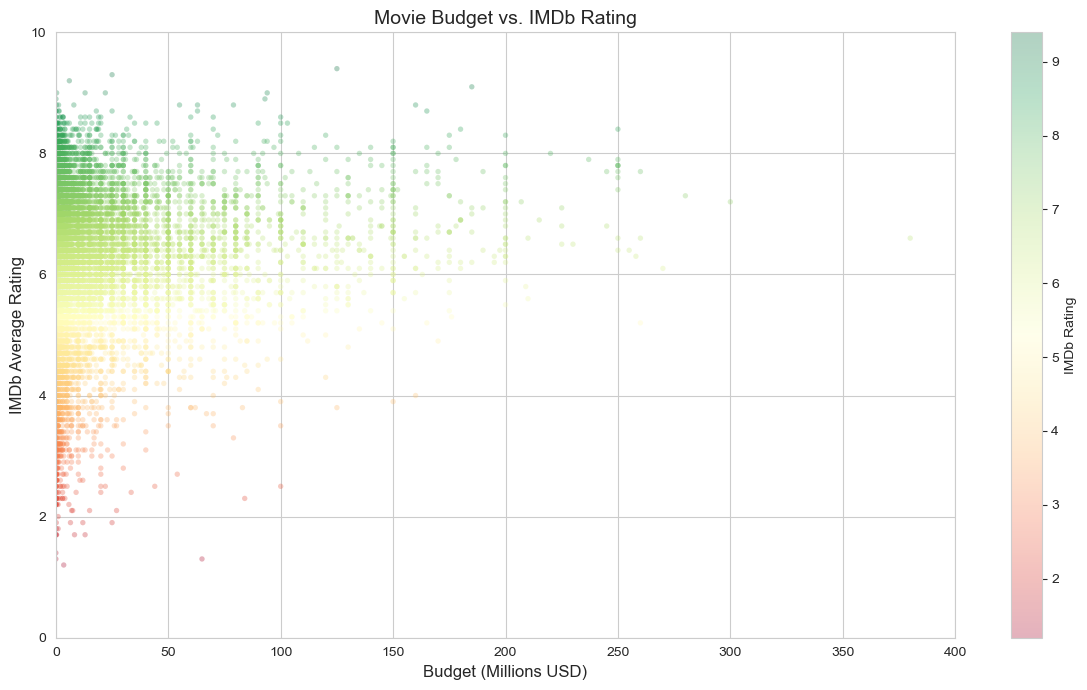

In [67]:
# Visual 1: Scatter plot of Budget vs IMDb Rating
# This directly visualizes the relationship between our two key variables

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_final['budget'] / 1e6,  # Convert to millions for readability
    df_final['averageRating'],
    alpha=0.3,
    s=15,
    c=df_final['averageRating'],
    cmap='RdYlGn',
    edgecolors='none'
)
plt.colorbar(scatter, label='IMDb Rating')
plt.xlabel('Budget (Millions USD)', fontsize=12)
plt.ylabel('IMDb Average Rating', fontsize=12)
plt.title('Movie Budget vs. IMDb Rating', fontsize=14)
plt.xlim(0, 400)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

*Answer to research question:* The scatter plot reveals that **there is no strong linear relationship between a movie's budget and its IMDb rating.** Movies across all budget ranges receive a wide spread of ratings, roughly between 4 and 8. However, extremely low-rated movies (below 4) are slightly more common among lower-budget films. Most high-budget movies (over $100M) tend to cluster in the 5.5–7.5 range, suggesting that larger budgets may provide a floor for ratings but do not guarantee exceptional reviews.

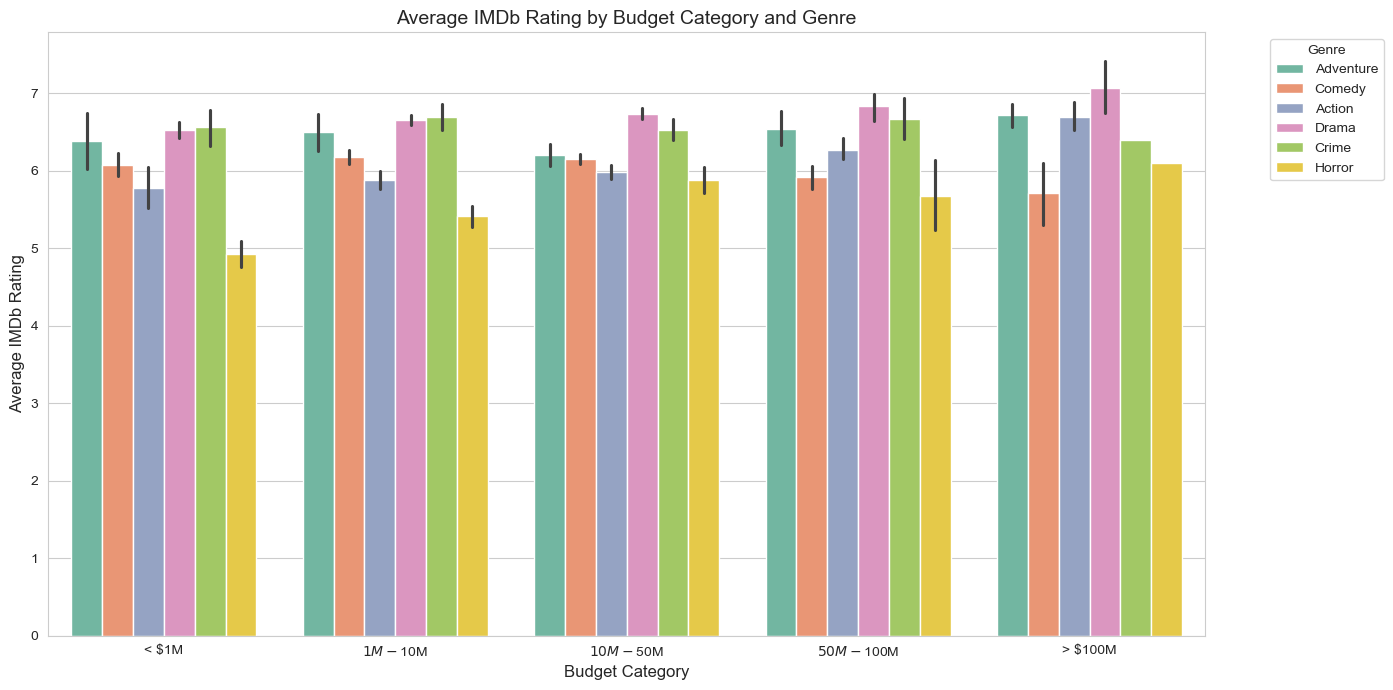

In [68]:
# Visual 2: Average IMDb Rating by Budget Category and Genre
# This breaks down the relationship by genre to reveal hidden patterns

# Create budget categories for clearer comparison
df_final['budget_category'] = pd.cut(
    df_final['budget'],
    bins=[0, 1e6, 1e7, 5e7, 1e8, float('inf')],
    labels=['< $1M', '$1M-$10M', '$10M-$50M', '$50M-$100M', '> $100M']
)

# Filter to top 6 genres for readability
top_genres = df_final['primary_genre'].value_counts().head(6).index
df_plot = df_final[df_final['primary_genre'].isin(top_genres)]

plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_plot,
    x='budget_category',
    y='averageRating',
    hue='primary_genre',
    palette='Set2'
)
plt.xlabel('Budget Category', fontsize=12)
plt.ylabel('Average IMDb Rating', fontsize=12)
plt.title('Average IMDb Rating by Budget Category and Genre', fontsize=14)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

*Answer to research question:* The grouped bar chart reveals that **the relationship between budget and rating depends heavily on genre.** Drama films consistently receive higher average ratings across all budget categories compared to other genres. Interestingly, for most genres, the difference in average rating between budget categories is relatively small (within 0.5–1.0 points), confirming that budget alone is not a strong predictor of audience reception. The most notable finding is that low-budget dramas often outperform high-budget action and comedy films, suggesting that storytelling quality matters more than production spending.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* If I had more time, I would investigate the `revenue` column more thoroughly to analyze return on investment (ROI = revenue/budget) and explore whether high-budget movies are actually more profitable, not just better-rated. I would also address additional data quality issues such as duplicate entries (some movies appear more than once with slightly different metadata) and inconsistencies in the `release_date` column formatting. Furthermore, I would explore time-series trends to determine whether the relationship between budget and ratings has changed over the decades, and I would incorporate additional data sources such as critic scores from Rotten Tomatoes to compare professional reviews with audience ratings.